In [2]:
#imports
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import importlib
import sys
import os
from astropy.cosmology import Planck18 as cosmo
import ast




In [10]:
# --- User toggle ---
Cristina = False
Shar = not Cristina 

# --- System Configurations ---

if Cristina:
    print("[CONFIG] Using Cristina's local MacBook setup")
    sys.path.insert(0, "/Users/andradenebula/Documents/Research/Transient_Metrics/Multi_Transient_Metrics_Hub")
    os.environ["RUBIN_SIM_DATA_DIR"] = "/Users/andradenebula/rubin_sim_data"
    db_dir = "/Users/andradenebula/Documents/Research/Transient_Metrics/Multi_Transient_Metrics_Hub"
    base_dir = None
    
elif Shar:
    print("[CONFIG] Using Shar's Dirac server setup")
    sys.path.insert(0, "/lustre/lrspec/metrics")
    sys.path.insert(0, "/home/3155/metrics/Multi_Transient_Metrics_Hub")
    os.environ["RUBIN_SIM_DATA_DIR"] = "/lustre/lrspec/metrics/rubin_sim_data"
    db_dir = "/lustre/lrspec/metrics"
    base_dir = '/lustre/lrspec/metrics/results'

# Shared config
sys.path.append(os.path.abspath(".."))  # For shared_utils


[CONFIG] Using Shar's Dirac server setup


In [15]:
#this happens twice because idk why but it only works like that
#...you still have to run it twice if it gives warnings
# C: Make sure you save your metric file before running. 

metric_filename = "new_names_local_GRBafterglows_metric"
s_u = "shared_utils"

# --- Reload metric module ---
if metric_filename in sys.modules:
    del sys.modules[metric_filename]
metric = __import__(metric_filename)
importlib.reload(metric)

# --- Reload shared_utils module ---
if s_u in sys.modules:
    del sys.modules[s_u]
shared_utils = __import__(s_u)
importlib.reload(shared_utils)

print(f"[INFO] Loaded metric module: {metric_filename}")
print(f"[INFO] Loaded shared_utils module")




[INFO] Loaded metric module: new_names_local_GRBafterglows_metric
[INFO] Loaded shared_utils module


In [16]:
#metric configurations
testname=None  
#use this to add text to the filename
#if you're testing template or population variables other than the below variables

testname_metric_only=None 
#use this to add text to the filename for the observation record df only (does not change pop/template filenames)
#so for anything you're changing that's only about the detection criteria

#control whether we generate new files - 
#new files will still generate if these are false and it can't find a file with the correct parameters
#so recommend leaving it on false
generate_new_templates = False 
generate_new_pop = False
make_debug_plots = True #toggle whether or not the pop generation makes plots

#population variables
rate_density = 1e-8

# apply None for non-use case 
z_min, z_max = .00226, .3
d_min, d_max = None, None #3000, 4000

#other
gal_lat_cut = None #latitude cut, for Galactic phenomena
use_extinction = False
t_start = 1 #start time in days
t_end = 3652

# Whether to remove Metric_temp_* folders after running
clean_temp = True  # <- NEW toggle

#cadence variables
cadences = ['four_roll_v4.3.1_10yrs', 'baseline_v4.3.1_10yrs','noroll_v3.6_10yrs']
ignore_triples = False #turn this to true to ignore triples

# Standardized output paths for this science case
# paths = metric.get_output_paths(case_label="GRBafterglows")  # <- can change to 'KNe' etc.
paths = shared_utils.build_filenames(testname=testname,
                        testname_metric_only=testname_metric_only,
                        science_case="GRBafterglows", 
                        rate_density=rate_density, 
                        z_min=z_min, 
                        z_max=z_max,
                        d_min=d_min, 
                        d_max=d_max,
                        ignore_triples=ignore_triples,                   
                        use_extinction=use_extinction,
                        base_dir=base_dir)


templates_file, pop_file, df_file, storage_dir, summary_filename = paths

GRBafterglows_den_1e-09_d_None-None_Mpc_z_0.00226-0.3_Mpc_ext_False_None


In [17]:
#load and/or generate light curves
shared_lc_model = metric.load_or_generate_templates(
    templates_file=templates_file,
    generate_new=generate_new_templates
)

[INFO] Loading light curve templates from /lustre/lrspec/metrics/results/GRBafterglows/GRBafterglows_den_1e-09_d_None-None_Mpc_z_0.00226-0.3_Mpc_ext_False_None_templates.pkl.
Loaded GRB afterglow templates from /lustre/lrspec/metrics/results/GRBafterglows/GRBafterglows_den_1e-09_d_None-None_Mpc_z_0.00226-0.3_Mpc_ext_False_None_templates.pkl


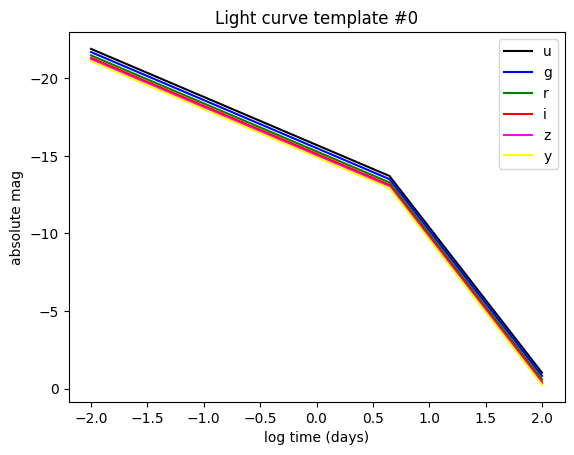

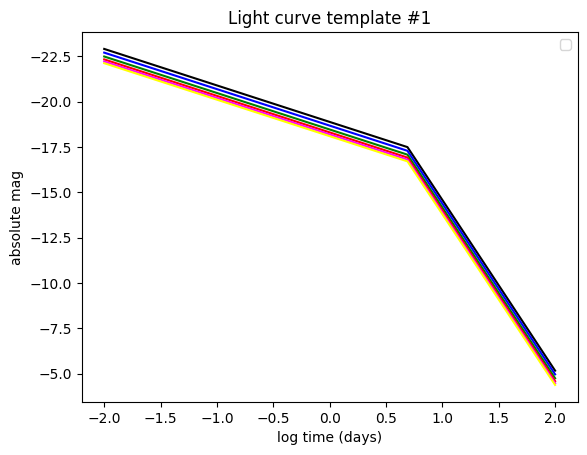

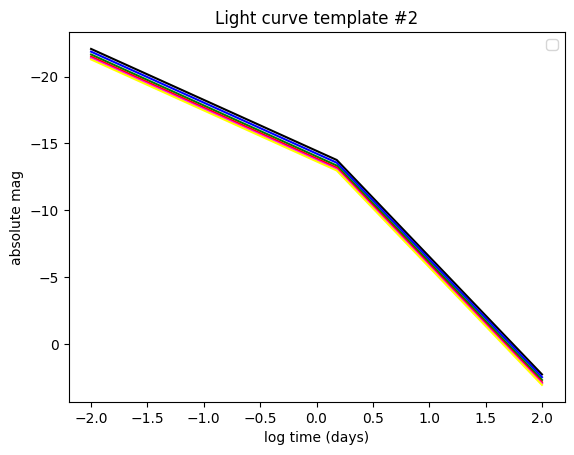

In [12]:
#plot light curves from pkl file if desired
shared_utils.plot_some_lcs_from_pkl(templates_file, num=3)

In [8]:
# Load or generate population slicer
slicer = shared_utils.load_or_generate_population(use_extinction=use_extinction,
    t_start=t_start,
    t_end=t_end,
    d_min=d_min,
    d_max=d_max,
    z_min=z_min,
    z_max=z_max,
    seed=42,
    num_lightcurves=1000,
    gal_lat_cut=gal_lat_cut,
    rate_density=rate_density,
    pop_file=pop_file,
    generate_new=generate_new_pop,
    make_debug_plots=make_debug_plots
)


[INFO] Loading population from /lustre/lrspec/metrics/results/GRBafterglows/GRBafterglows_den_1e-09_d_None-None_Mpc_z_0.00226-0.3_Mpc_ext_False_None_population.pkl
Loaded population from /lustre/lrspec/metrics/results/GRBafterglows/GRBafterglows_den_1e-09_d_None-None_Mpc_z_0.00226-0.3_Mpc_ext_False_None_population.pkl


## All 10 years


--- Running four_roll_v4.3.1_10yrs ---

Inspecting one obs_record before saving to CSV:
mjd_obs         | type: <class 'list'> | length: 754
mag_obs         | type: <class 'list'> | length: 754
snr_obs         | type: <class 'list'> | length: 754
filter          | type: <class 'list'> | length: 754
first_det_mjd   | type: <class 'float'> | value: nan
last_det_mjd    | type: <class 'float'> | value: nan
fade_time_days  | type: <class 'float'> | value: nan
sid_duplicate   | type: <class 'numpy.int64'> | value: 1
file_indx       | type: <class 'numpy.int64'> | value: 591
ra              | type: <class 'numpy.float64'> | value: 0.6135923151542564
dec             | type: <class 'numpy.float64'> | value: -0.5848608108840141
distance_Mpc    | type: <class 'numpy.float64'> | value: 555.5229467106975
peak_mjd_observed | type: <class 'numpy.float64'> | value: 62142.12798620133
peak_mag_observed | type: <class 'numpy.float64'> | value: 27.79159390141482
ebv             | type: <class 'numpy.floa

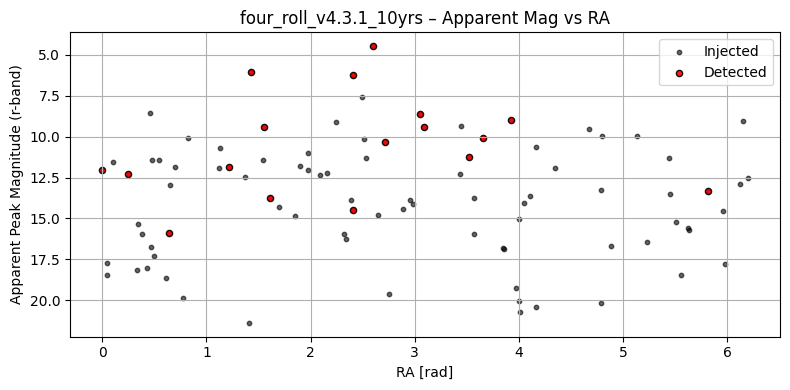

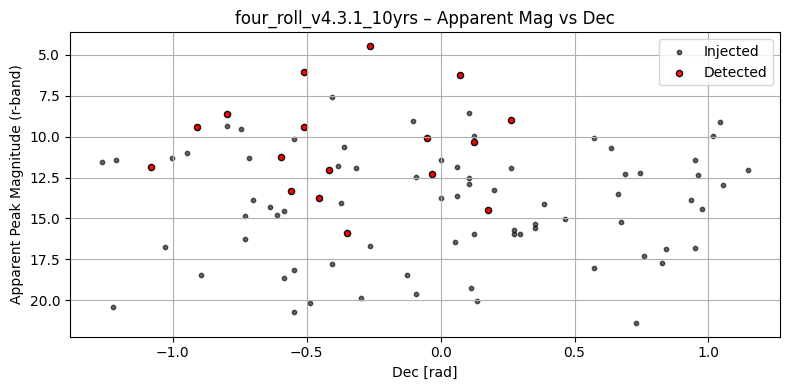

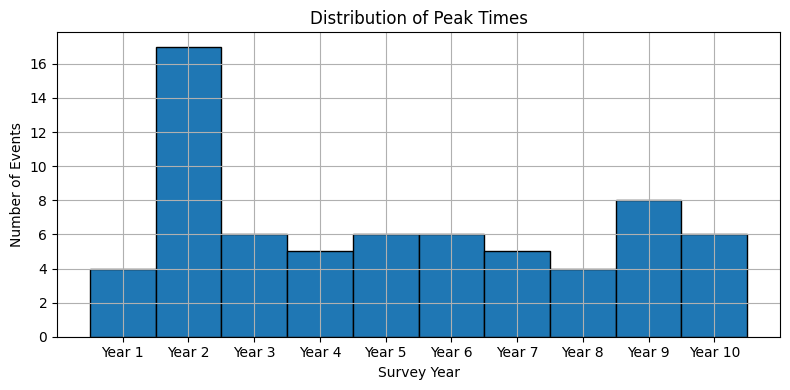

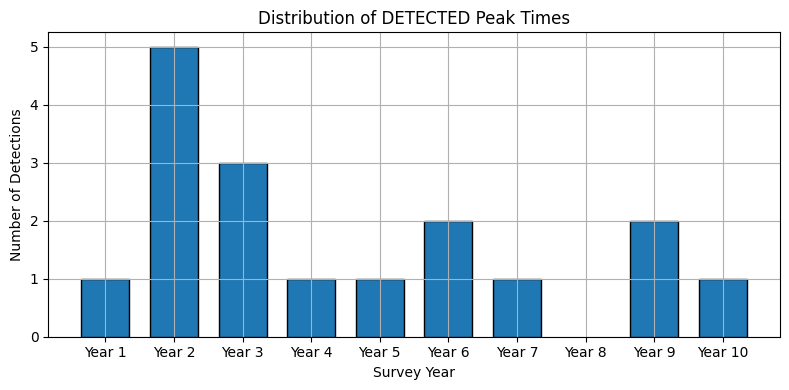

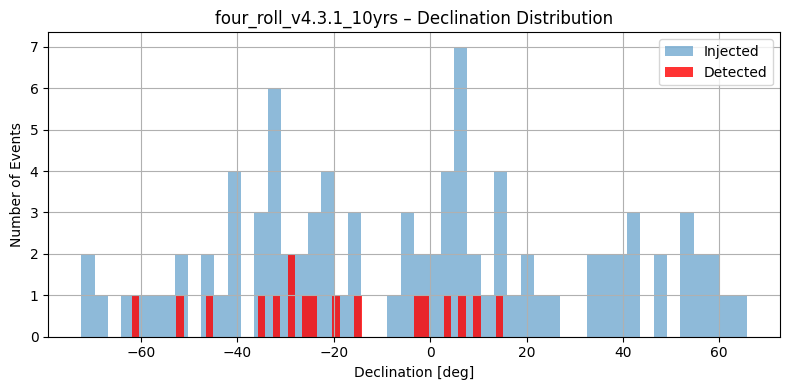


--- Running baseline_v4.3.1_10yrs ---

Inspecting one obs_record before saving to CSV:
mjd_obs         | type: <class 'list'> | length: 778
mag_obs         | type: <class 'list'> | length: 778
snr_obs         | type: <class 'list'> | length: 778
filter          | type: <class 'list'> | length: 778
first_det_mjd   | type: <class 'float'> | value: nan
last_det_mjd    | type: <class 'float'> | value: nan
fade_time_days  | type: <class 'float'> | value: nan
sid_duplicate   | type: <class 'numpy.int64'> | value: 1
file_indx       | type: <class 'numpy.int64'> | value: 591
ra              | type: <class 'numpy.float64'> | value: 0.6135923151542564
dec             | type: <class 'numpy.float64'> | value: -0.5848608108840141
distance_Mpc    | type: <class 'numpy.float64'> | value: 555.5229467106975
peak_mjd_observed | type: <class 'numpy.float64'> | value: 62149.06253031362
peak_mag_observed | type: <class 'numpy.float64'> | value: 28.583843516159348
ebv             | type: <class 'numpy.floa

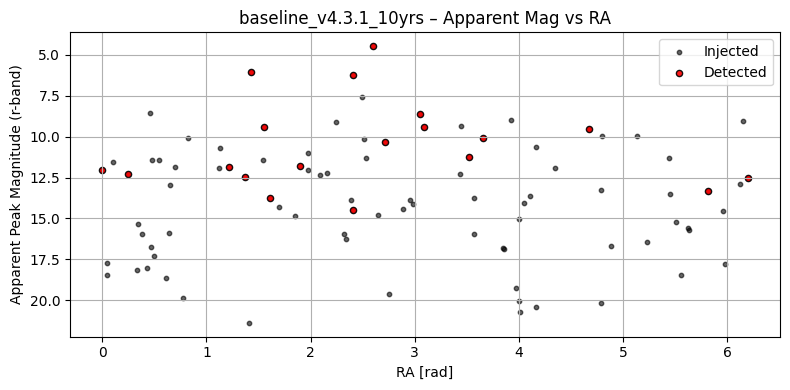

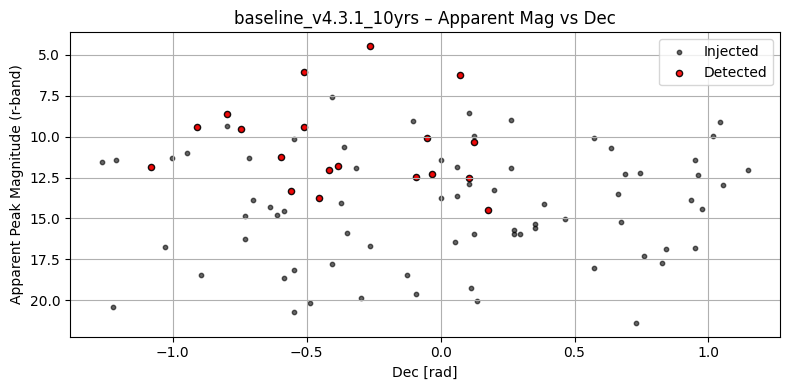

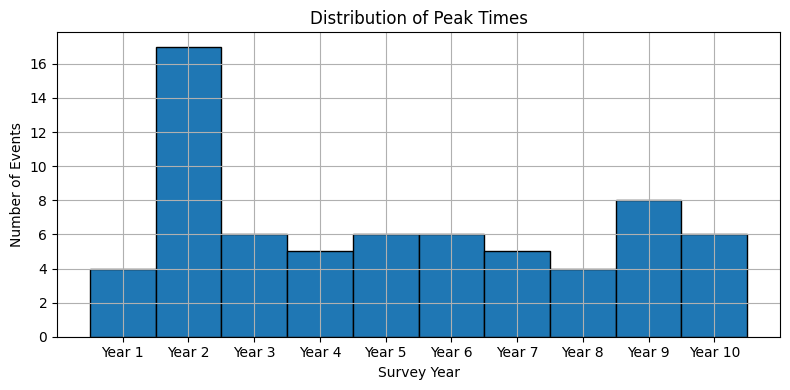

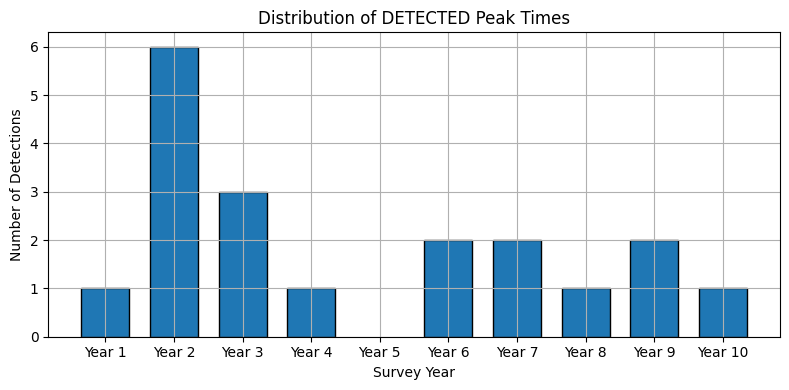

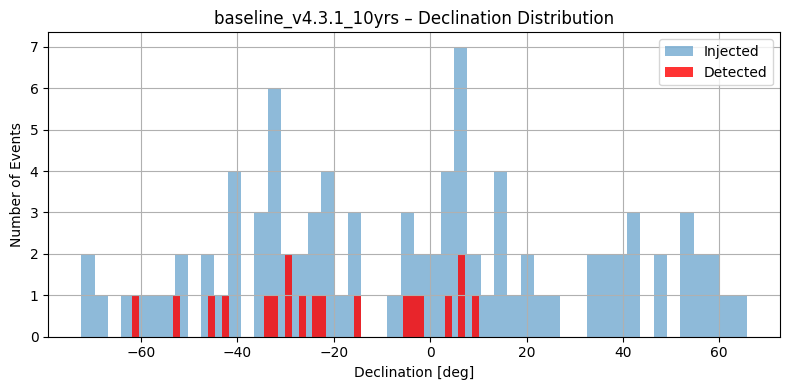


--- Running noroll_v3.6_10yrs ---

Inspecting one obs_record before saving to CSV:
mjd_obs         | type: <class 'list'> | length: 747
mag_obs         | type: <class 'list'> | length: 747
snr_obs         | type: <class 'list'> | length: 747
filter          | type: <class 'list'> | length: 747
first_det_mjd   | type: <class 'float'> | value: nan
last_det_mjd    | type: <class 'float'> | value: nan
fade_time_days  | type: <class 'float'> | value: nan
sid_duplicate   | type: <class 'numpy.int64'> | value: 1
file_indx       | type: <class 'numpy.int64'> | value: 591
ra              | type: <class 'numpy.float64'> | value: 0.6135923151542564
dec             | type: <class 'numpy.float64'> | value: -0.5848608108840141
distance_Mpc    | type: <class 'numpy.float64'> | value: 555.5229467106975
peak_mjd_observed | type: <class 'numpy.float64'> | value: 62148.05692675825
peak_mag_observed | type: <class 'numpy.float64'> | value: 29.016949859774286
ebv             | type: <class 'numpy.float64'

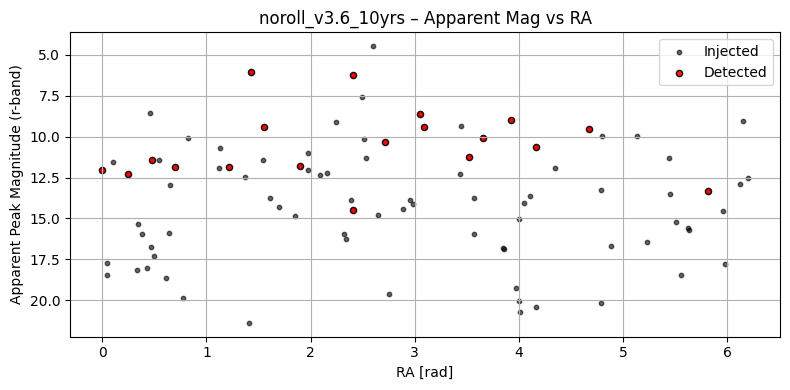

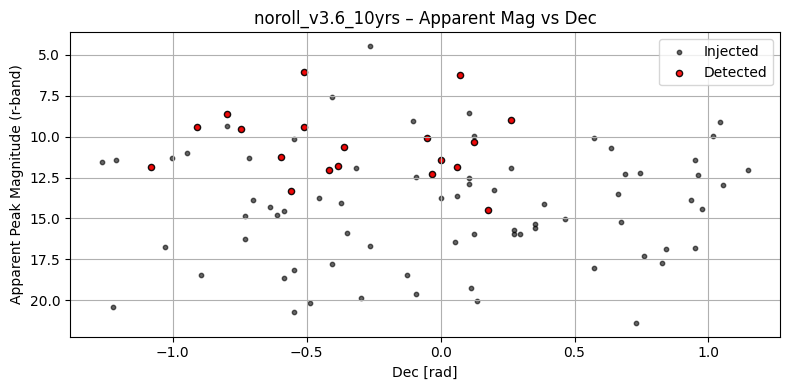

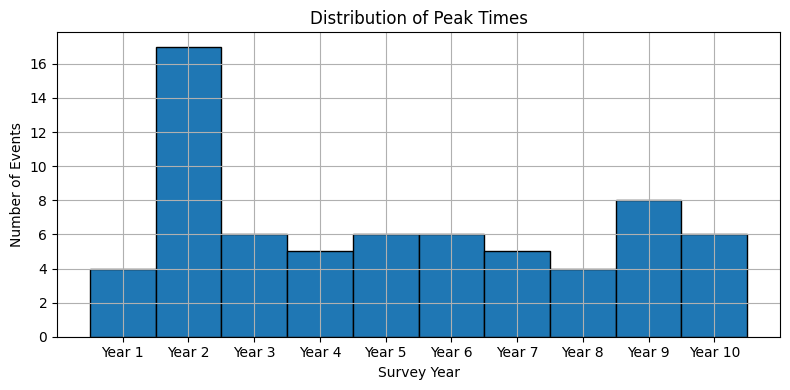

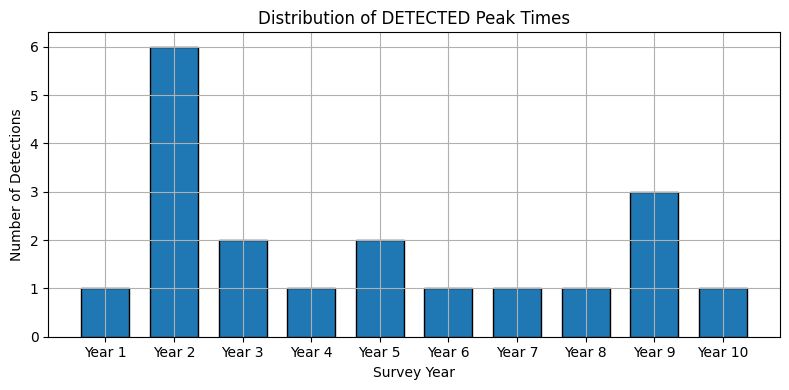

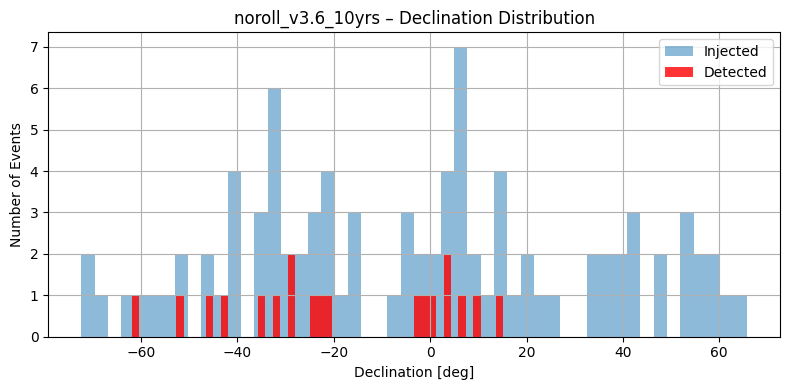

In [11]:
#run detection metric
df_obs = shared_utils.run_detect(metric, slicer, cadences, shared_lc_model, db_dir, storage_dir, df_file, ignore_triples=ignore_triples, debug=True, plot=True, clean_temp=clean_temp, use_extinction=use_extinction)

In [18]:
#choose what to run in run_multi_metrics
# we can remove historical if we want
multi_metrics = metric.get_multi_metrics(shared_lc_model, include=['detect', 'characterize', 'spec_trigger'], use_extinction=use_extinction)


In [25]:
summary_df

,Unnamed: 0,Sum,run,n_events
0,four_roll_v4.3.1_10yrs_Detect_Metric,17.0,four_roll_v4.3.1_10yrs,91
1,four_roll_v4.3.1_10yrs_GRBAfterglowCharacteriz...,15.0,four_roll_v4.3.1_10yrs,91
2,four_roll_v4.3.1_10yrs_GRBAfterglowSpecTrigger...,16.0,four_roll_v4.3.1_10yrs,91
3,baseline_v4.3.1_10yrs_Detect_Metric,19.0,baseline_v4.3.1_10yrs,91
4,baseline_v4.3.1_10yrs_GRBAfterglowCharacterize...,14.0,baseline_v4.3.1_10yrs,91
5,baseline_v4.3.1_10yrs_GRBAfterglowSpecTriggera...,17.0,baseline_v4.3.1_10yrs,91
6,noroll_v3.6_10yrs_Detect_Metric,19.0,noroll_v3.6_10yrs,91
7,noroll_v3.6_10yrs_GRBAfterglowCharacterizeMetric,19.0,noroll_v3.6_10yrs,91
8,noroll_v3.6_10yrs_GRBAfterglowSpecTriggerableM...,16.0,noroll_v3.6_10yrs,91



--- Running four_roll_v4.3.1_10yrs ---


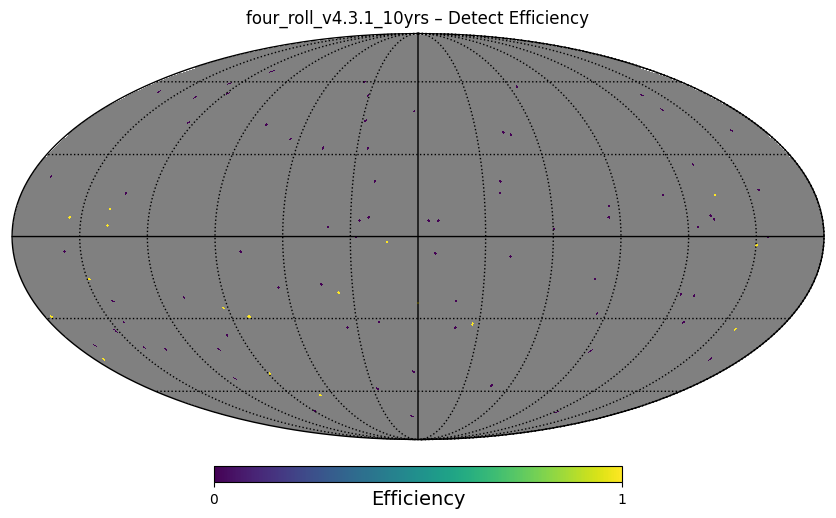

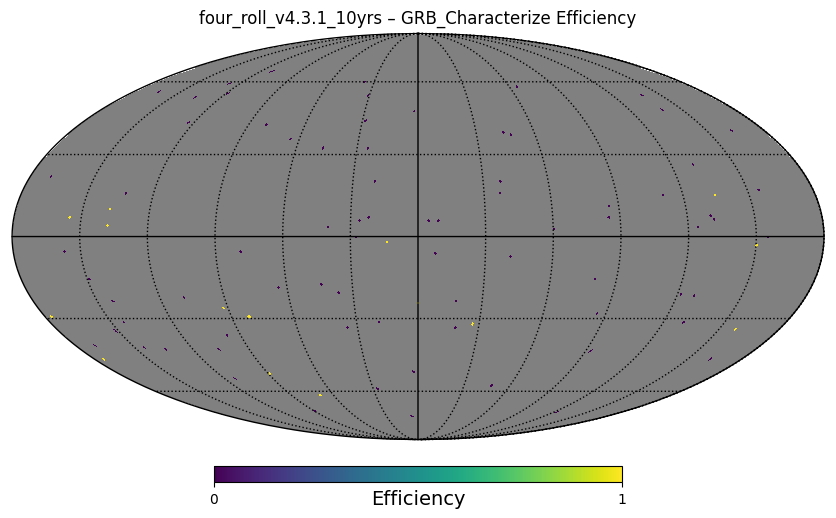

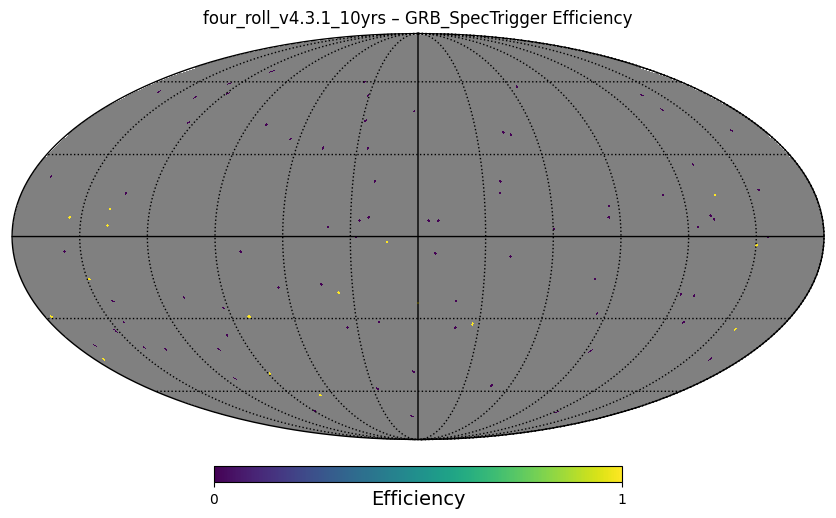

[CLEANUP] Removing temp directory: /lustre/lrspec/metrics/results/GRBafterglows/Metric_temp_four_roll_v4.3.1_10yrs
[CLEANUP] Removing temp directory: /lustre/lrspec/metrics/results/GRBafterglows/Metric_temp_baseline_v4.3.1_10yrs
[CLEANUP] Removing temp directory: /lustre/lrspec/metrics/results/GRBafterglows/Metric_temp_noroll_v3.6_10yrs

--- Running baseline_v4.3.1_10yrs ---


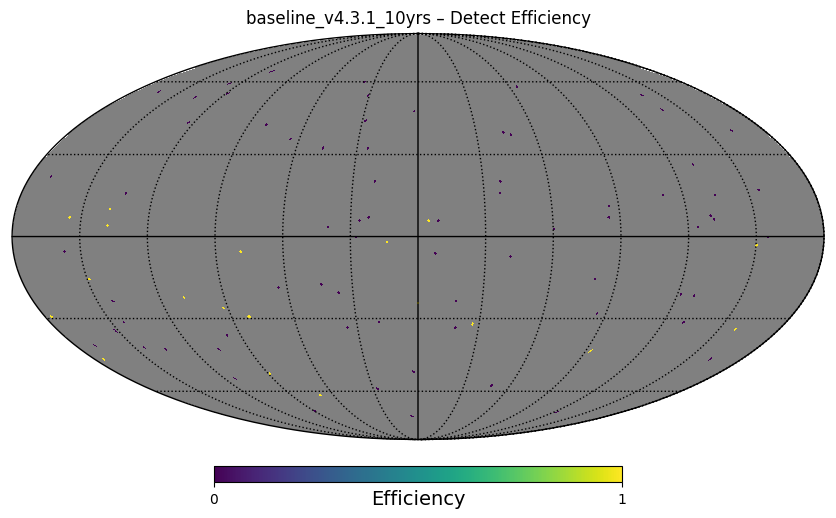

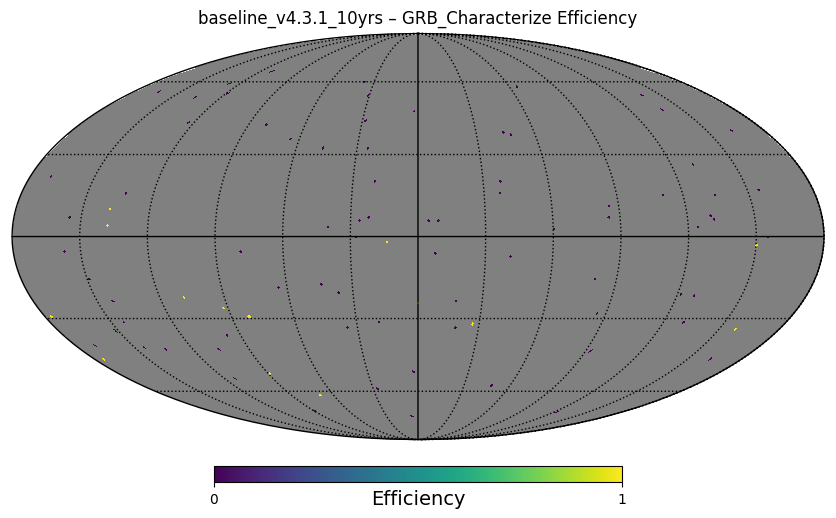

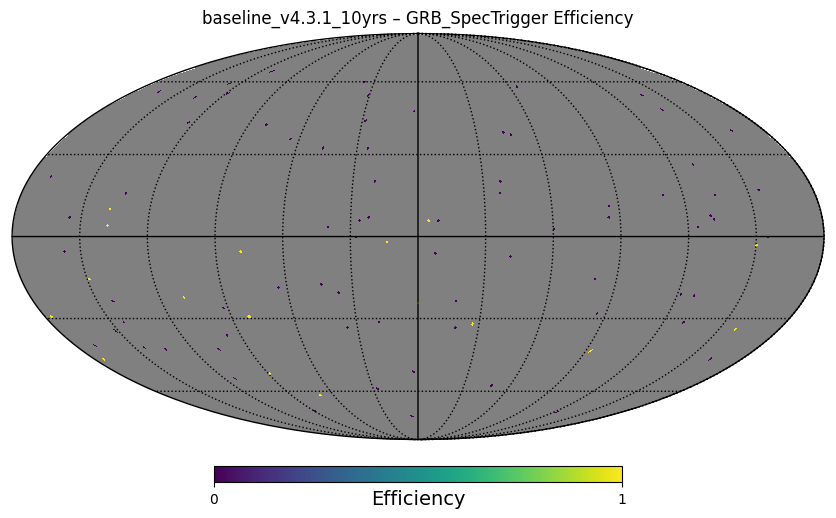

[CLEANUP] Removing temp directory: /lustre/lrspec/metrics/results/GRBafterglows/Metric_temp_four_roll_v4.3.1_10yrs
[CLEANUP] Removing temp directory: /lustre/lrspec/metrics/results/GRBafterglows/Metric_temp_baseline_v4.3.1_10yrs
[CLEANUP] Removing temp directory: /lustre/lrspec/metrics/results/GRBafterglows/Metric_temp_noroll_v3.6_10yrs

--- Running noroll_v3.6_10yrs ---


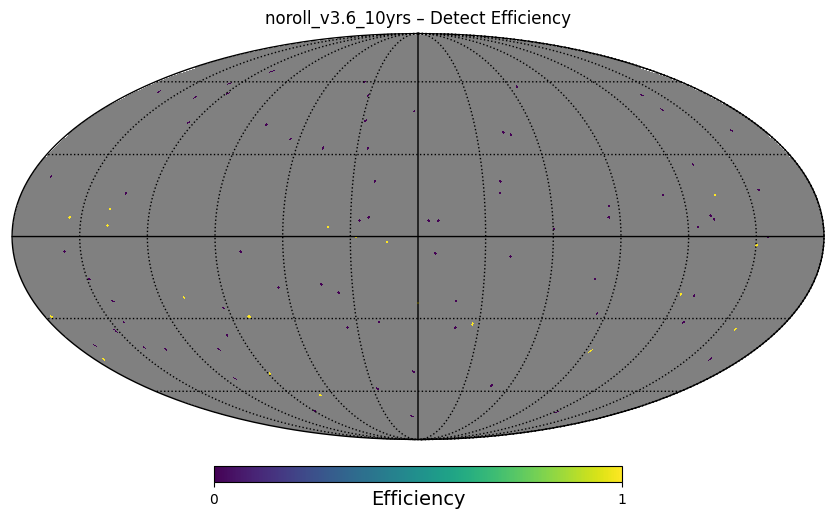

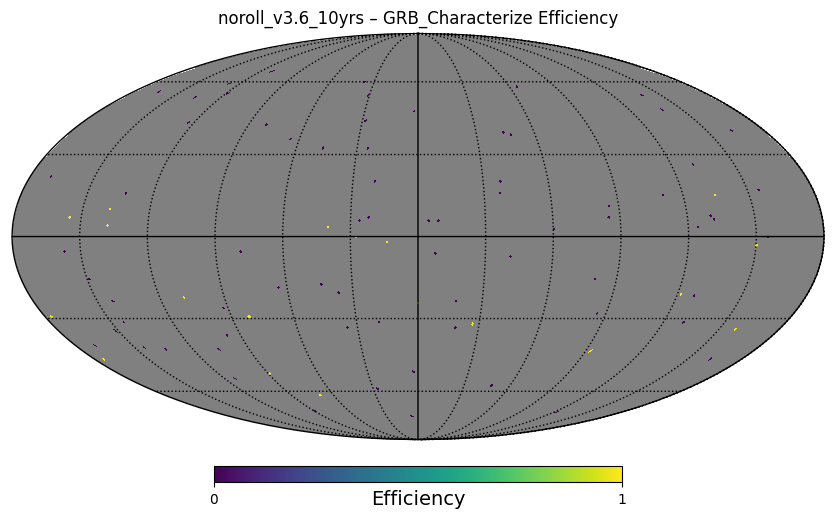

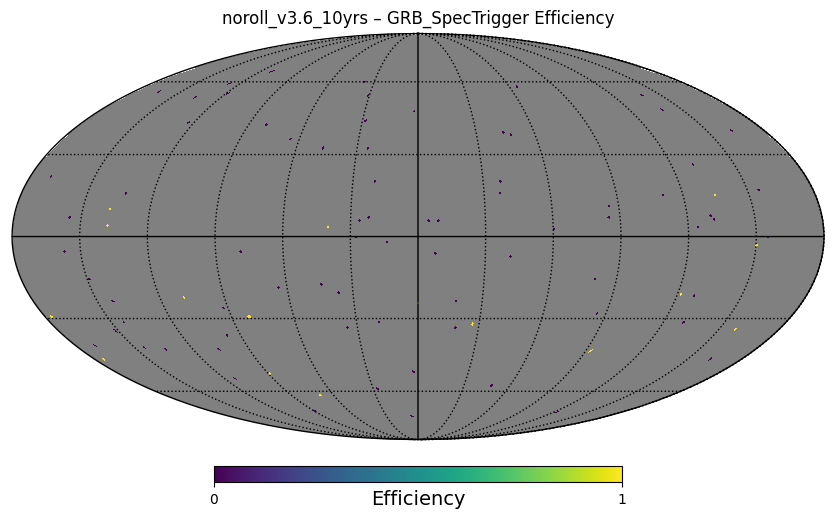

[CLEANUP] Removing temp directory: /lustre/lrspec/metrics/results/GRBafterglows/Metric_temp_four_roll_v4.3.1_10yrs
[CLEANUP] Removing temp directory: /lustre/lrspec/metrics/results/GRBafterglows/Metric_temp_baseline_v4.3.1_10yrs
[CLEANUP] Removing temp directory: /lustre/lrspec/metrics/results/GRBafterglows/Metric_temp_noroll_v3.6_10yrs
saved summary to  /lustre/lrspec/metrics/results/GRBafterglows/GRBafterglows_den_1e-09_d_None-None_Mpc_z_0.00226-0.3_Mpc_ext_False_None_None_multi_summary


In [20]:
summary_df = shared_utils.run_multi_metrics(multi_metrics, slicer, cadences, shared_lc_model, db_dir, storage_dir, summary_filename=summary_filename, ignore_triples=False, plot=True, clean_temp=clean_temp, use_extinction=use_extinction)